# 03 — Come si calcola τ_opp sui dati SkillCorner

**La domanda.** Come si passa dal tracking SkillCorner al numero τ_opp di
Narizuka et al., passo per passo, e il numero che esce a mano coincide con
quello di `scripts/calcola_tau.py`?

Non è un'esplorazione dei risultati (quelli stanno in `reports/tau_opp.md`): è la
spiegazione del calcolo, su **un possesso solo**, con ogni passaggio visibile.

**Fonti.**
- Paper: Narizuka, Sakamoto, Yamamoto, Yamazaki, *Quantifying defensive pressure
  on the ball carrier in soccer based on minimum arrival time* (arXiv:2606.09452),
  §2.2 e §2.3. Scheda: `notes/letteratura/pressione-tempo-arrivo.md`.
- Modello del moto: Fujimura & Sugihara, citato dal paper come [9]; parametri
  validati dagli stessi autori in [13].
- Codice: `lib/pressione.py` (modello), `scripts/calcola_tau.py` (tutte le partite),
  `tests/test_tempo_arrivo.py` (criteri fissati prima del codice).

**Percorso.**
1. Cosa misura τ_opp
2. Il modello del moto: da dove vengono il cerchio e i due parametri
3. Dal modello al tempo di arrivo: l'equazione e il primo attraversamento
4. Cosa serve da SkillCorner e dove si trova
5. Le velocità, che nei dati non ci sono
6. Un possesso, per filo e per segno
7. Al rilascio, e lungo tutto il possesso
8. Verifica contro lo script
9. Cosa è del paper e cosa è nostro

In [1]:
import sys
sys.path.append("..")
sys.path.append("../scripts")

import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mplsoccer import Pitch

from lib import data
from lib.pressione import ALPHA, V_MAX, tempo_arrivo, velocita, _eccesso
from lib.viz import BG, HOME_C, AWAY_C, SCIA, INK, MUTED
import calcola_tau

pd.set_option("display.width", 140)
pd.set_option("display.precision", 3)

MATCH_ID = 1886347
EVENT_ID = "8_781"   # un possesso di centrocampo, scelto perché è istruttivo (vedi §6)
FPS = 10

## 1. Cosa misura τ_opp

Il paper (§2.3) definisce, per il portatore di palla in posizione $\vec x_b$ al
tempo $t$:

$$
\tau_{\rm opp}(\vec x_b, t) = \min_{p \,\in\, \text{avversari}} \tau_p(\vec x_b, t)
$$

dove $\tau_p$ è il **tempo minimo che il giocatore $p$ impiega a raggiungere il
punto $\vec x_b$**, partendo dalla sua posizione e dalla sua velocità al tempo $t$.

In parole: *quanti secondi servono all'avversario più rapido per arrivare dove
sta il portatore adesso.* Più è piccolo, più la pressione è forte.

Il paper lo estrae in due istanti di ogni possesso individuale:

| simbolo | istante | nei dati SkillCorner |
|---|---|---|
| $t_{\rm get}$ | inizio del possesso | `frame_start` del `player_possession` |
| $t_{\rm rel}$ | rilascio della palla | `frame_end` del `player_possession` |

Se $t_{\rm rel} = t_{\rm get}$ il possesso è un **direct play** (tocco di prima);
altrimenti è un **possession play**. I possessi dei portieri sono esclusi.

Tre cose che τ_opp **non** fa, e che conviene avere chiare subito:
- non guarda dove va la palla dopo, solo dove sta il portatore;
- non conta quanti avversari ci sono vicino: conta solo il più rapido;
- non è un modello statistico: non si addestra nulla, è fisica applicata a
  posizioni e velocità.

## 2. Il modello del moto (paper §2.2, eq. 1–3)

Ogni giocatore è una massa $m$ spinta da una forza costante di modulo $F$ in una
direzione $\vec n$ a scelta, e frenata da un attrito viscoso $k$:

$$
m \frac{d^2 \vec x}{dt^2} = F \vec n - k \frac{d\vec x}{dt} \qquad \text{(eq. 1)}
$$

Dividendo per $m$ e chiamando $\alpha = k/m$ e $V_{\max} = F/k$:

$$
\frac{d\vec v}{dt} = \alpha\,(V_{\max}\vec n - \vec v)
$$

È un'equazione lineare del primo ordine nella velocità: la velocità si avvicina
esponenzialmente a $V_{\max}\vec n$,

$$
\vec v(t) = V_{\max}\vec n + (\vec v_0 - V_{\max}\vec n)\,e^{-\alpha t}.
$$

Integrando una volta di più si ottiene la posizione (eq. 2–3 del paper):

$$
\vec x(t) = \underbrace{\vec x_0 + \frac{1 - e^{-\alpha t}}{\alpha}\,\vec v_0}_{\vec c(t)}
\;+\; \underbrace{V_{\max}\!\left(t - \frac{1 - e^{-\alpha t}}{\alpha}\right)}_{r(t)}\,\vec n
$$

La lettura è la parte importante:

- **$\vec c(t)$ non dipende da $\vec n$.** È dove il giocatore finirebbe per pura
  inerzia, se smettesse di spingere: parte da $\vec x_0$ e scivola nella direzione
  in cui stava già correndo, sempre più piano.
- **$r(t)$ non dipende dalla direzione.** È quanto riesce a spostarsi rispetto a
  quel punto spingendo in una direzione qualunque.
- Quindi l'insieme dei punti raggiungibili al tempo $t$ è un **cerchio** di
  centro $\vec c(t)$ e raggio $r(t)$. La velocità attuale sposta il cerchio, non
  lo allarga.

**I due parametri** (dal lavoro di validazione degli stessi autori, [13]):

| | valore | significato fisico |
|---|---|---|
| $\alpha$ | 1,0 s⁻¹ | costante di tempo di 1 s: da fermo, dopo 1 s si è al 63% della velocità massima |
| $V_{\max}$ | 10,0 m/s | velocità asintotica, 36 km/h |

Sono fissati nei test (`test_parametri_del_paper`): è una replica, non una
calibrazione. Ma vanno confrontati con i nostri giocatori, qui sotto.

In [2]:
def centro(t, x0, v0, alpha=ALPHA):
    # c(t): dove porta l'inerzia
    return np.asarray(x0) + (1 - np.exp(-alpha * t)) / alpha * np.asarray(v0)

def raggio(t, alpha=ALPHA, vmax=V_MAX):
    # r(t): quanto ci si sposta spingendo
    return vmax * (t - (1 - np.exp(-alpha * t)) / alpha)

print(f"alpha = {ALPHA} 1/s,  V_max = {V_MAX} m/s")
for t in (0.5, 1, 2, 3):
    v = V_MAX * (1 - np.exp(-ALPHA * t))
    print(f"da fermo, dopo {t:>3} s: velocità {v:4.1f} m/s, spazio percorso {raggio(t):5.2f} m")

alpha = 1.0 1/s,  V_max = 10.0 m/s
da fermo, dopo 0.5 s: velocità  3.9 m/s, spazio percorso  1.07 m
da fermo, dopo   1 s: velocità  6.3 m/s, spazio percorso  3.68 m
da fermo, dopo   2 s: velocità  8.6 m/s, spazio percorso 11.35 m
da fermo, dopo   3 s: velocità  9.5 m/s, spazio percorso 20.50 m


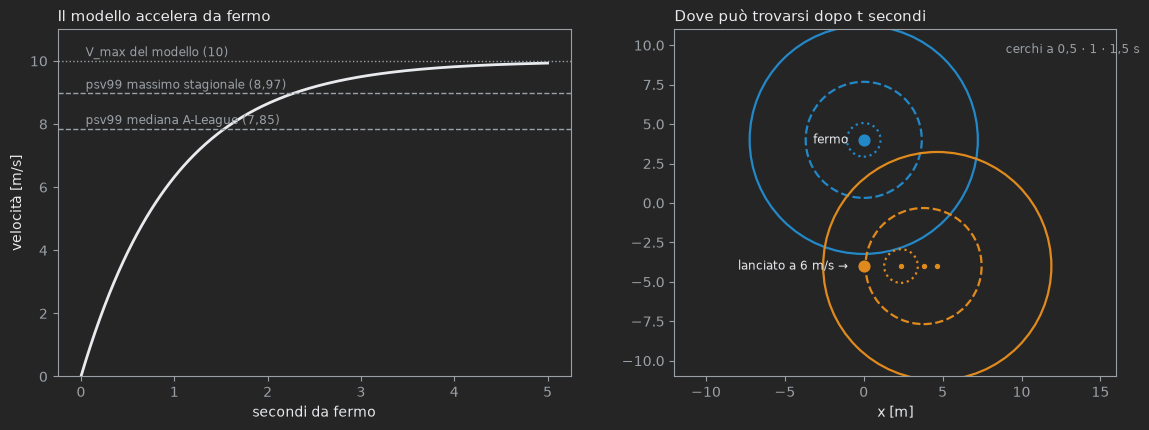

In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.4), facecolor=BG)
for a in (a1, a2):
    a.set_facecolor(BG)
    a.tick_params(colors=MUTED)
    for s in a.spines.values():
        s.set_color(MUTED)

# Sinistra: la velocità da fermo secondo il modello, contro le velocità di punta A-League
t = np.linspace(0, 5, 300)
a1.plot(t, V_MAX * (1 - np.exp(-ALPHA * t)), color=INK, lw=2)
for val, nome in ((7.85, "psv99 mediana A-League (7,85)"), (8.97, "psv99 massimo stagionale (8,97)")):
    a1.axhline(val, color=MUTED, lw=1, ls="--")
    a1.text(0.05, val + 0.15, nome, color=MUTED, fontsize=8.5)
a1.axhline(V_MAX, color=MUTED, lw=1, ls=":")
a1.text(0.05, V_MAX + 0.15, "V_max del modello (10)", color=MUTED, fontsize=8.5)
a1.set_xlabel("secondi da fermo", color=INK)
a1.set_ylabel("velocità [m/s]", color=INK)
a1.set_title("Il modello accelera da fermo", color=INK, loc="left", fontsize=10.5)
a1.set_ylim(0, 11)

# Destra: cerchi raggiungibili, giocatore fermo contro giocatore lanciato a 6 m/s verso destra
for x0, v0, col, nome, dy in (((0, 4), (0, 0), HOME_C, "fermo", 4), ((0, -4), (6, 0), AWAY_C, "lanciato a 6 m/s →", -4)):
    a2.scatter(*x0, color=col, s=60, zorder=3)
    a2.text(x0[0] - 1, x0[1], nome, color=INK, fontsize=8.5, ha="right", va="center")
    for tt, ls in ((0.5, ":"), (1.0, "--"), (1.5, "-")):
        c = centro(tt, x0, v0)
        a2.add_patch(Circle(c, raggio(tt), fill=False, color=col, ls=ls, lw=1.6))
        a2.scatter(*c, color=col, s=8)
a2.text(9, 9.5, "cerchi a 0,5 · 1 · 1,5 s", color=MUTED, fontsize=8.5)
a2.set_aspect("equal")
a2.set_xlim(-12, 16); a2.set_ylim(-11, 11)
a2.set_xlabel("x [m]", color=INK)
a2.set_title("Dove può trovarsi dopo t secondi", color=INK, loc="left", fontsize=10.5)
plt.tight_layout()
plt.show()

**Cosa dice la figura.**

- A sinistra: il modello non raggiunge mai davvero 10 m/s, e nei primi 2 s resta
  sotto la velocità di punta tipica dell'A-League. Nell'arco di tempo che conta
  per τ_opp (quasi sempre sotto i 2–3 s) il limite di 10 m/s non è quasi mai
  "attivo": pesa soprattutto $\alpha$, cioè l'accelerazione.
- A destra: il cerchio del giocatore lanciato ha **lo stesso raggio** di quello
  del giocatore fermo, ma è **spostato** nella direzione della corsa. Per questo
  un avversario che corre verso il portatore arriva prima di uno fermo alla
  stessa distanza, e uno che corre via arriva dopo.

## 3. Dal modello al tempo di arrivo (paper eq. 4)

Il giocatore $p$ può trovarsi nel punto $\vec x$ al tempo $\tau$ quando $\vec x$
è dentro il suo cerchio. Il tempo di arrivo è il primo istante in cui il bordo
del cerchio tocca il punto:

$$
r_p(\tau_p) = \lVert \vec x - \vec c_p(\tau_p) \rVert \qquad \text{(eq. 4)}
$$

Non c'è una formula chiusa comoda: il paper dice *"computed by numerically
solving"*. Per un giocatore **fermo** l'equazione si riduce a
$d = V_{\max}\,(\tau - (1 - e^{-\alpha\tau})/\alpha)$, e dà la scala dei numeri
che leggeremo dopo:

In [4]:
righe = []
for d in (1, 2, 5, 10, 20, 30):
    tau = tempo_arrivo((0.0, 0.0), (0.0, 0.0), (d, 0.0))
    residuo = raggio(tau) - d
    righe.append({"distanza [m]": d, "τ da fermo [s]": tau, "residuo eq. 4 [m]": residuo})
pd.DataFrame(righe)

,distanza [m],τ da fermo [s],residuo eq. 4 [m]
0,1,0.483,-3.186e-14
1,2,0.707,1.776e-15
2,5,1.198,0.000e+00
3,10,1.841,5.656e-12
4,20,2.948,-3.338e-10
5,30,3.981,4.263e-14


**Scala di riferimento:** 5 m ≈ 1,2 s, 10 m ≈ 1,8 s. Un τ_opp di 0,5 s vuol dire
un avversario fermo a circa 1 m, oppure più lontano ma già lanciato verso il
portatore.

Ora la velocità. Stesso bersaglio a 10 m, velocità iniziale di 5 m/s in tre
direzioni diverse (sono anche i test `test_correre_*`):

In [5]:
pd.DataFrame([
    {"direzione della corsa": nome, "τ [s]": tempo_arrivo((0.0, 0.0), v, (10.0, 0.0))}
    for nome, v in (("fermo", (0.0, 0.0)), ("verso il bersaglio", (5.0, 0.0)),
                    ("di lato", (0.0, 5.0)), ("in direzione opposta", (-5.0, 0.0)))
])

,direzione della corsa,τ [s]
0,fermo,1.841
1,verso il bersaglio,1.373
2,di lato,1.945
3,in direzione opposta,2.358


### Perché serve il *primo* attraversamento

Sembra un dettaglio numerico, ma cambia il risultato. Definiamo lo scarto
$f(t) = r(t) - \lVert \vec x - \vec c(t)\rVert$: è negativo finché il punto è
fuori portata, e il tempo di arrivo è il primo $t$ con $f(t) \ge 0$.

Con una velocità iniziale alta, **$f$ può cambiare segno più di una volta.**
Esempio: giocatore lanciato a 6 m/s verso un punto a 1 m davanti a sé. Ci arriva
quasi subito; poi l'inerzia lo porta oltre, e per un tratto il modello dice che
*in quell'istante* non può più trovarsi lì (non riesce a frenare abbastanza); più
tardi il cerchio, allargandosi, ricopre di nuovo il punto.

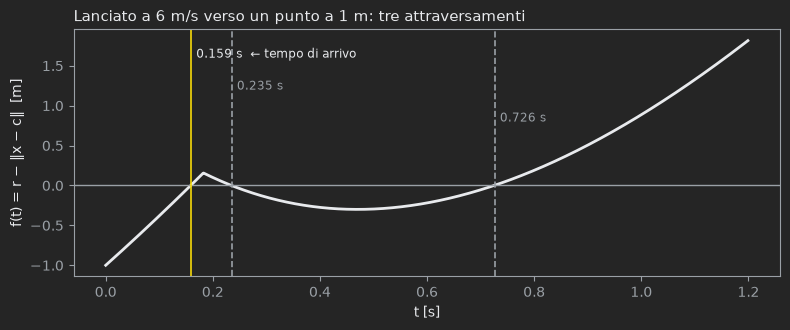

attraversamenti: [0.159 0.235 0.726]
tempo_arrivo restituisce: 0.159


In [6]:
t = np.arange(0, 1.2, 0.001)
x0, v0, bers = np.array([0.0, 0.0]), np.array([6.0, 0.0]), np.array([1.0, 0.0])
f = _eccesso(t, x0, v0, bers, ALPHA, V_MAX)
cambi = t[1:][np.sign(f[1:]) != np.sign(f[:-1])]

fig, ax = plt.subplots(figsize=(8, 3.4), facecolor=BG)
ax.set_facecolor(BG); ax.tick_params(colors=MUTED)
for s in ax.spines.values():
    s.set_color(MUTED)
ax.plot(t, f, color=INK, lw=2)
ax.axhline(0, color=MUTED, lw=1)
for i, tc in enumerate(cambi):
    ax.axvline(tc, color=SCIA if i == 0 else MUTED, lw=1.2, ls="-" if i == 0 else "--")
    ax.text(tc + 0.01, 1.6 - 0.4 * i, f"{tc:.3f} s" + ("  ← tempo di arrivo" if i == 0 else ""),
            color=INK if i == 0 else MUTED, fontsize=8.5)
ax.set_xlabel("t [s]", color=INK)
ax.set_ylabel("f(t) = r − ‖x − c‖  [m]", color=INK)
ax.set_title("Lanciato a 6 m/s verso un punto a 1 m: tre attraversamenti", color=INK, loc="left", fontsize=10.5)
plt.tight_layout(); plt.show()

print("attraversamenti:", np.round(cambi, 3))
print("tempo_arrivo restituisce:", round(tempo_arrivo(x0, v0, bers), 3))

Un risolutore generico su $[0, T]$ (bisezione, `brentq`, `fsolve` con un punto di
partenza qualunque) potrebbe restituire uno qualsiasi dei tre. Per questo
`tempo_arrivo` in `lib/pressione.py`:

1. se il punto è già dentro il cerchio a $t=0$ (distanza zero) restituisce 0;
2. valuta $f$ su una griglia da 0,01 s fino a 30 s;
3. prende il **primo** intervallo in cui $f$ diventa $\ge 0$;
4. raffina dentro quell'intervallo con `brentq` (precisione $10^{-9}$ s).

Nei casi reali di τ_opp il problema è raro (servono velocità alte e distanze molto
piccole), ma quando capita è proprio nei casi di pressione massima, dove l'errore
peserebbe di più. Ecco il codice:

In [7]:
print(inspect.getsource(tempo_arrivo))

def tempo_arrivo(pos, vel, bersaglio, alpha=ALPHA, vmax=V_MAX) -> float:
    """Tempo minimo perché un giocatore in `pos` con velocità `vel` raggiunga `bersaglio`."""
    pos = np.asarray(pos, dtype=float)
    vel = np.asarray(vel, dtype=float)
    bersaglio = np.asarray(bersaglio, dtype=float)
    if not (np.isfinite(pos).all() and np.isfinite(vel).all() and np.isfinite(bersaglio).all()):
        return np.nan
    if _eccesso(0.0, pos, vel, bersaglio, alpha, vmax) >= 0:
        return 0.0

    t0 = 0.0
    while True:
        t = np.arange(t0, t0 + _T_MAX + _DT, _DT)
        f = _eccesso(t, pos, vel, bersaglio, alpha, vmax)
        idx = np.flatnonzero(f >= 0)
        if idx.size:
            k = idx[0]
            if f[k] == 0:
                return float(t[k])
            return float(brentq(_eccesso, t[k - 1], t[k],
                                args=(pos, vel, bersaglio, alpha, vmax), xtol=1e-9))
        t0 = t[-1]



## 4. Cosa serve da SkillCorner e dove si trova

| Ingrediente del modello | File | Campo |
|---|---|---|
| intervallo del possesso, $t_{\rm get}$ e $t_{\rm rel}$ | `{id}_dynamic_events.csv` | `event_type == "player_possession"`, `frame_start`, `frame_end` |
| chi è il portatore, di che squadra, in che ruolo | `dynamic_events.csv` | `player_id`, `team_id`, `player_position` (per escludere `GK`) |
| posizione del portatore $\vec x_b$ | `{id}_tracking_extrapolated.jsonl` | `player_data[*].x, y` del portatore a quel frame |
| posizioni degli avversari $\vec x_p(0)$ | tracking | `player_data[*].x, y` |
| **velocità** degli avversari $\vec v_p(0)$ | **non c'è** | va derivata dalle posizioni (§5) |
| chi è avversario di chi | `{id}_match.json` | `players[*].team_id` |
| se la posizione è osservata | tracking | `player_data[*].is_detected` (kloppy non lo espone) |

Coordinate in metri, origine al centro del campo, 10 frame al secondo. Il
`frame` è la chiave che lega eventi e tracking.

Una scelta da dichiarare: il paper usa la *"ball-carrier location"*. Noi prendiamo
la posizione di tracking **del giocatore** in possesso, non quella della palla
(`ball_data`), che è estrapolata più spesso e in un contrasto può essere a un paio
di metri dal portatore.

**Attenzione alle coordinate degli eventi.** `x_start`, `y_start` di
`dynamic_events.csv` **non** sono nel sistema del tracking: quando la squadra
attacca `right_to_left` sono ruotate di 180° (x e y cambiano segno), così che negli
eventi si attacchi sempre verso +x. Verificato su tutte le 20 partite: scarto
mediano fra 0 e 0,26 m dopo la rotazione. Qui sotto si vede sul nostro possesso:
`x_start = −9,27` negli eventi, portatore a x = +9,02 nel tracking. Per questo
tutte le posizioni del calcolo vengono dal tracking, e la direzione d'attacco (che
serve per la distanza dalla porta) da `attacking_side`.

In [8]:
meta = data.load_match_meta(MATCH_ID)
squadra = {p["id"]: p["team_id"] for p in meta["players"]}
nome = {p["id"]: p.get("short_name") or p.get("last_name") for p in meta["players"]}
ruolo = {p["id"]: p["player_role"]["acronym"] for p in meta["players"]}
squadre = {meta["home_team"]["id"]: meta["home_team"]["short_name"],
           meta["away_team"]["id"]: meta["away_team"]["short_name"]}
colore = {meta["home_team"]["id"]: HOME_C, meta["away_team"]["id"]: AWAY_C}

de = data.load_dynamic_events(MATCH_ID)
ev = de[de.event_id == EVENT_ID].iloc[0]
ev[["event_type", "player_name", "player_position", "team_shortname", "period",
    "time_start", "time_end", "frame_start", "frame_end", "attacking_side",
    "start_type", "end_type", "pass_outcome", "x_start", "y_start",
    "time_to_impact_start", "time_to_impact_end"]].to_frame("valore")

,valore
event_type,player_possession
player_name,K. Grozos
player_position,RDM
team_shortname,Newcastle
period,2
time_start,71:48.8
time_end,71:50.9
frame_start,43888
frame_end,43909
attacking_side,right_to_left


Il possesso dura `frame_end − frame_start` frame, cioè a 10 fps un decimo di
secondo per frame. Ecco com'è fatto un frame grezzo del tracking al
`frame_start` (i primi tre giocatori):

In [9]:
fr = next(f for f in data.iter_tracking(MATCH_ID) if f["frame"] == ev.frame_start)
print({k: fr[k] for k in ("frame", "timestamp", "period", "ball_data", "possession")})
for p in fr["player_data"][:3]:
    print(p)
print(f"... {len(fr['player_data'])} giocatori in questo frame")

{'frame': 43888, 'timestamp': '01:11:48.80', 'period': 2, 'ball_data': {'x': 8.57, 'y': 25.09, 'z': 0.14, 'is_detected': True}, 'possession': {'player_id': None, 'group': 'away team'}}
{'x': -33.06, 'y': 5.22, 'player_id': 285188, 'is_detected': False}
{'x': -7.2, 'y': 4.79, 'player_id': 51667, 'is_detected': False}
{'x': -7.73, 'y': 14.58, 'player_id': 33697, 'is_detected': False}
... 22 giocatori in questo frame


In [10]:
# Tutta la partita in array frame × giocatore: X, Y, is_detected (D), periodo del frame.
# È la stessa funzione usata dallo script sulle 20 partite.
f0, col, X, Y, D, periodo = calcola_tau.carica_tracking(MATCH_ID)
print(f"primo frame {f0}, {X.shape[0]} frame × {X.shape[1]} giocatori")
print(f"frame con tracking: {np.isfinite(X).any(axis=1).mean():.1%}")

primo frame 0, 59061 frame × 29 giocatori
frame con tracking: 73.6%


## 5. Le velocità, che nei dati non ci sono

Il modello ha bisogno di $\vec v_p(0)$, la velocità di ogni avversario
nell'istante considerato. SkillCorner non la fornisce (le colonne di velocità di
kloppy sono vuote su questi dati), quindi si deriva dalle posizioni.

**Derivata centrale**, con $\Delta t = 0{,}1$ s:

$$
v_x(i) = \frac{x(i+1) - x(i-1)}{2\,\Delta t}, \qquad v_y(i) = \frac{y(i+1) - y(i-1)}{2\,\Delta t}
$$

È la stima simmetrica: usa un frame prima e uno dopo, quindi non introduce ritardo
(una differenza all'indietro sarebbe in ritardo di mezzo frame). È `np.gradient`,
che agli estremi di un tratto passa alla differenza unilaterale.

**Perché senza lisciatura**, a differenza del paper (che usa Savitzky–Golay e
spline cubica su dati a 25 fps): le traiettorie SkillCorner arrivano già
lisciate. Misurato sulla partita 1886347: nessuna velocità sopra i 10 m/s,
accelerazione al 99° percentile 4,5 m/s², e una Savitzky–Golay da 5 a 15 frame
sposta i numeri di pochi centesimi (`notes/dati/tracking-extrapolated.md`). La
scelta è fissata nei test (`FINESTRA_LISCIATURA = None`) prima di vedere i risultati.

Due dettagli del calcolo:
- **per periodo**: la derivata non deve scavalcare l'intervallo;
- **i buchi**: nei frame senza tracking (gioco fermo, replay) la posizione è NaN,
  e la derivata centrale nei frame adiacenti a un buco resta NaN, perché un vicino
  manca. Non si inventa una velocità.

In [11]:
VX, VY = calcola_tau.velocita_per_periodo(X, Y, periodo)

# Controllo a mano sul portatore, al frame_start: la formula sopra contro l'array
i, j = ev.frame_start - f0, col[ev.player_id]
vx_mano = (X[i + 1, j] - X[i - 1, j]) / (2 / FPS)
vy_mano = (Y[i + 1, j] - Y[i - 1, j]) / (2 / FPS)
print(f"a mano: ({vx_mano:.3f}, {vy_mano:.3f}) m/s   array: ({VX[i, j]:.3f}, {VY[i, j]:.3f}) m/s")

v = np.hypot(VX, VY)
v = v[np.isfinite(v)]
print(f"velocità su tutta la partita, tutti i giocatori: mediana {np.median(v):.2f} m/s, "
      f"99° percentile {np.percentile(v, 99):.2f}, massimo {v.max():.2f}")
print(f"sopra i 10 m/s (V_max del modello): {(v > 10).mean():.3%}")

a mano: (-2.450, -2.500) m/s   array: (-2.450, -2.500) m/s
velocità su tutta la partita, tutti i giocatori: mediana 1.73 m/s, 99° percentile 6.43, massimo 13.89
sopra i 10 m/s (V_max del modello): 0.005%


La formula a mano e l'array coincidono. Le velocità sono plausibili (99° percentile
6,4 m/s), ma **il massimo non lo è**: 13,9 m/s sono 50 km/h, oltre il record
umano. È uno 0,005% di valori, un salto nelle posizioni che la derivata
trasforma in un picco. La nota `notes/dati/tracking-extrapolated.md` dice "0,0%
sopra i 10 m/s": è corretto come arrotondamento, ma i picchi esistono. Su τ_opp
pesano solo se cadono sull'avversario giusto nel frame giusto; non si filtrano,
per coerenza con la scelta "nessuna lisciatura", ma vanno tenuti presenti.

## 6. Un possesso, per filo e per segno

Il calcolo di τ_opp in un istante sono cinque passi:

1. dal numero di frame all'indice di riga: `i = frame − f0`;
2. la posizione del portatore $\vec x_b$ = `X[i, portatore]`, `Y[i, portatore]`;
3. gli avversari = i giocatori della **squadra opposta** presenti in quel frame
   (tutti 11: il tracking è tutto-o-niente);
4. per ciascuno, posizione e velocità a quel frame → `tempo_arrivo(pos, vel, x_b)`;
5. τ_opp = il minimo. Si annota anche **chi** lo realizza, e se era osservato.

La funzione qui sotto fa esattamente questo e restituisce la tabella completa,
non solo il minimo. `v verso il portatore` è la componente della velocità lungo
la congiungente: positiva se l'avversario si sta avvicinando.

In [12]:
def dettaglio(frame, portatore):
    i = int(frame) - f0
    jb = col[portatore]
    xb = np.array([X[i, jb], Y[i, jb]])
    righe = []
    for pid, j in col.items():
        if squadra[pid] == squadra[portatore] or not np.isfinite(X[i, j]):
            continue
        pos, vel = np.array([X[i, j], Y[i, j]]), np.array([VX[i, j], VY[i, j]])
        verso = xb - pos
        dist = np.hypot(*verso)
        righe.append({
            "player_id": pid, "giocatore": nome[pid], "ruolo": ruolo[pid],
            "distanza [m]": dist,
            "velocità [m/s]": np.hypot(*vel),
            "v verso il portatore [m/s]": vel @ verso / dist,
            "τ [s]": tempo_arrivo(pos, vel, xb),
            "osservato": bool(D[i, j]),
        })
    tab = pd.DataFrame(righe).sort_values("τ [s]").reset_index(drop=True)
    return xb, tab

xb_get, tab_get = dettaglio(ev.frame_start, ev.player_id)
print(f"portatore {nome[ev.player_id]} ({ruolo[ev.player_id]}, {squadre[squadra[ev.player_id]]}) "
      f"in ({xb_get[0]:.2f}, {xb_get[1]:.2f}), osservato: {bool(D[ev.frame_start - f0, col[ev.player_id]])}")
print(f"τ_opp(t_get) = {tab_get['τ [s]'].min():.3f} s")
tab_get

portatore K. Grozos (RDM, Newcastle) in (9.02, 25.10), osservato: True
τ_opp(t_get) = 1.151 s


,player_id,giocatore,ruolo,distanza [m],velocità [m/s],v verso il portatore [m/s],τ [s],osservato
0,14736,L. Verstraete,DM,5.562,5.070,2.776,1.151,True
1,133498,F. De Vries,LB,4.768,3.720,0.341,1.231,True
2,965685,L. Gillion,LW,7.275,2.804,2.683,1.253,True
3,23418,F. Gallegos,AM,10.446,4.269,3.447,1.592,True
4,43829,N. Moreno,RW,15.317,4.014,1.104,2.381,True
5,50951,J. Brimmer,CF,16.300,1.400,1.400,2.413,True
6,38673,G. May,CF,19.131,3.669,1.990,2.683,True
7,33697,N. Pijnaker,LCB,19.780,1.953,-1.705,3.097,False
8,51667,D. Hall,RCB,25.992,1.991,-0.350,3.613,False
9,51713,C. Elliott,RB,34.637,1.665,0.833,4.372,True


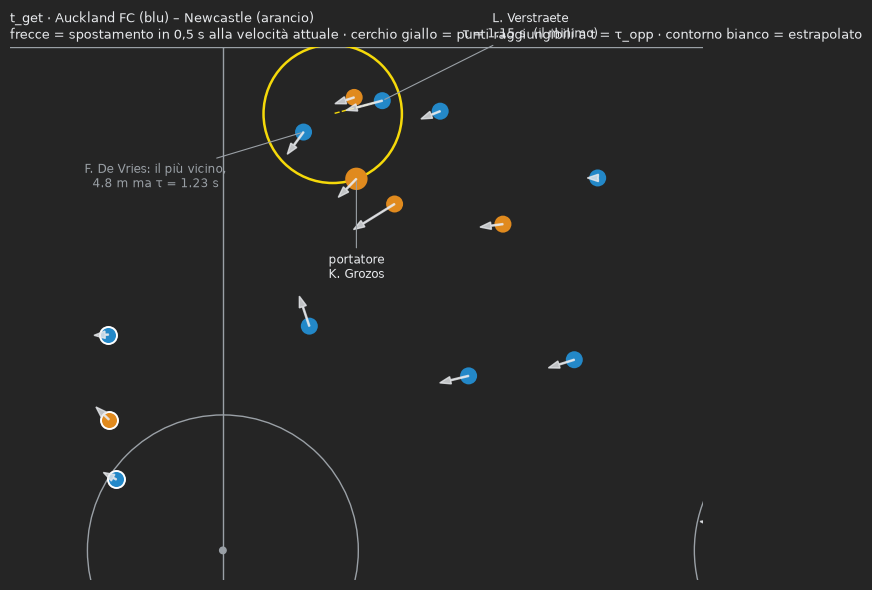

In [13]:
def disegna(frame, portatore, tab, titolo, raggio_vista=18):
    i = int(frame) - f0
    xb = np.array([X[i, col[portatore]], Y[i, col[portatore]]])
    pitch = Pitch(pitch_type="skillcorner", pitch_length=meta["pitch_length"],
                  pitch_width=meta["pitch_width"], pitch_color=BG, line_color=MUTED, linewidth=1)
    fig, ax = pitch.draw(figsize=(8, 6))
    fig.set_facecolor(BG)

    # tutti i giocatori: riempimento = squadra, contorno bianco = estrapolato (convenzione di lib/viz.py)
    for pid, j in col.items():
        if not np.isfinite(X[i, j]):
            continue
        ax.scatter(X[i, j], Y[i, j], s=260 if pid == portatore else 150, color=colore[squadra[pid]],
                   edgecolors="#ffffff" if not D[i, j] else "none", linewidths=1.4, zorder=3)
        ax.arrow(X[i, j], Y[i, j], VX[i, j] * 0.5, VY[i, j] * 0.5, color=INK, width=0.08,
                 head_width=0.5, length_includes_head=True, alpha=0.8, zorder=4)

    # il cerchio raggiungibile dell'avversario che realizza τ_opp, a t = τ_opp: tocca il portatore
    best = tab.iloc[0]
    jb = col[best.player_id]
    tau = best["τ [s]"]
    c = centro(tau, (X[i, jb], Y[i, jb]), (VX[i, jb], VY[i, jb]))
    ax.add_patch(Circle(c, raggio(tau), fill=False, color=SCIA, lw=1.8, zorder=2))
    ax.plot([X[i, jb], c[0]], [Y[i, jb], c[1]], color=SCIA, lw=1, ls="--", zorder=2)

    # etichette con linea di richiamo, spostate lontano dal portatore per non sovrapporsi
    def etichetta(x, y, testo, colore_testo, dx, dy):
        ax.annotate(testo, (x, y), xytext=(x + dx, y + dy), color=colore_testo, fontsize=8.5,
                    ha="center", va="center", zorder=6,
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
    etichetta(xb[0], xb[1], f"portatore\n{nome[portatore]}", INK, 0, -6)
    etichetta(X[i, jb], Y[i, jb], f"{nome[best.player_id]}\nτ = {tau:.2f} s  (il minimo)", INK, 10, 5)
    vicino = tab.sort_values("distanza [m]").iloc[0]
    if vicino.player_id != best.player_id:
        jv = col[vicino.player_id]
        etichetta(X[i, jv], Y[i, jv],
                  f"{nome[vicino.player_id]}: il più vicino,\n{vicino['distanza [m]']:.1f} m ma τ = {vicino['τ [s]']:.2f} s",
                  MUTED, -10, -3)

    semi_l, semi_w = meta["pitch_length"] / 2, meta["pitch_width"] / 2
    cx = np.clip(xb[0], -semi_l + raggio_vista * 1.3, semi_l - raggio_vista * 1.3)
    cy = np.clip(xb[1], -semi_w + raggio_vista, semi_w - raggio_vista)
    ax.set_xlim(cx - raggio_vista * 1.3, cx + raggio_vista * 1.3)
    ax.set_ylim(cy - raggio_vista, cy + raggio_vista)
    ax.set_title(titolo + "\nfrecce = spostamento in 0,5 s alla velocità attuale · cerchio giallo = "
                 "punti raggiungibili a t = τ_opp · contorno bianco = estrapolato",
                 color=INK, fontsize=9, loc="left")
    plt.show()

disegna(ev.frame_start, ev.player_id, tab_get,
        f"t_get · {squadre[meta['home_team']['id']]} (blu) – {squadre[meta['away_team']['id']]} (arancio)")

In [14]:
# Quanto conta la velocità: gli stessi tre avversari, se fossero fermi alla stessa distanza
tab_get.head(3).assign(**{"τ se fosse fermo [s]": lambda t: [
    tempo_arrivo((0.0, 0.0), (0.0, 0.0), (d, 0.0)) for d in t["distanza [m]"]]})[
    ["giocatore", "distanza [m]", "v verso il portatore [m/s]", "τ [s]", "τ se fosse fermo [s]"]]

,giocatore,distanza [m],v verso il portatore [m/s],τ [s],τ se fosse fermo [s]
0,L. Verstraete,5.562,2.776,1.151,1.278
1,F. De Vries,4.768,0.341,1.231,1.165
2,L. Gillion,7.275,2.683,1.253,1.506


**Cosa si vede a t_get.**

- Il portatore, Grozos (mediano del Newcastle), riceve sulla fascia, a 9 m dalla
  linea laterale.
- **L'avversario più vicino non è quello che realizza τ_opp.** De Vries è a 4,8 m
  ma si muove quasi di lato rispetto al portatore (0,3 m/s verso di lui): τ =
  1,23 s, **più** di quanto impiegherebbe da fermo (1,17 s), perché prima deve
  vincere l'inerzia laterale. Verstraete è più lontano, 5,6 m, ma corre verso il
  portatore a 2,8 m/s: τ = 1,15 s, contro 1,28 s da fermo. È il caso che una misura di sola distanza non vede, ed è il motivo
  per cui il modello usa le velocità.
- **Il minimo nasconde quanti avversari ci sono.** I primi tre sono entro 0,1 s
  l'uno dall'altro: tre giocatori arrivano quasi insieme, ma τ_opp registra solo
  il primo. È una scelta del paper (§2.3), non un errore, e va ricordata quando si
  interpreta il numero.
- **Qualità del dato:** i sette avversari più rapidi sono tutti osservati; quelli
  estrapolati sono oltre i 19 m, lontani dal portatore. È la situazione favorevole
  che la scheda del paper aveva previsto (dati buoni vicino alla palla).

## 7. Al rilascio, e lungo tutto il possesso

Stesso calcolo a `frame_end`, cioè $t_{\rm rel}$:

τ_opp(t_rel) = 0.817 s   (t_get: 1.151 s, differenza +0.334 s)


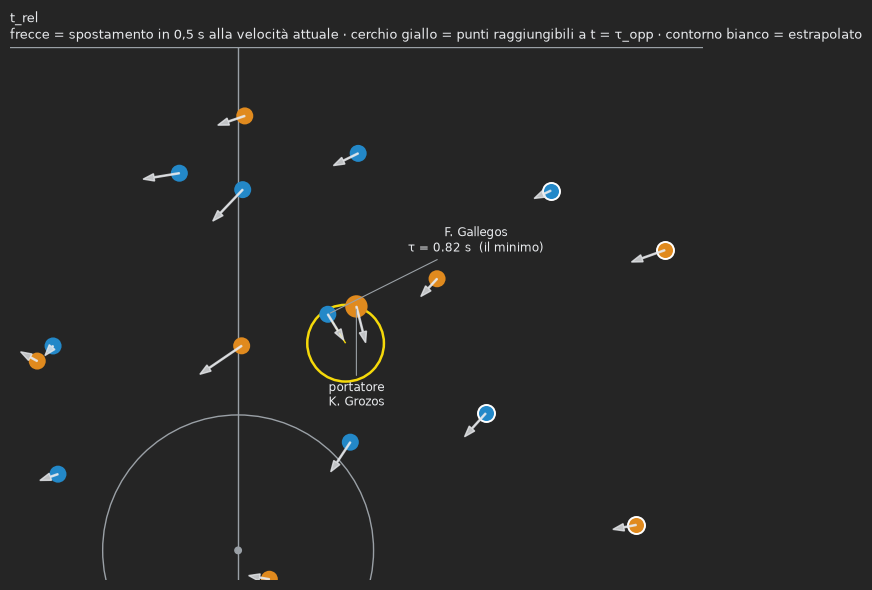

,player_id,giocatore,ruolo,distanza [m],velocità [m/s],v verso il portatore [m/s],τ [s],osservato
0,23418,F. Gallegos,AM,2.001,4.108,1.146,0.817,True
1,965685,L. Gillion,LW,10.341,3.734,1.689,1.764,True
2,38673,G. May,CF,11.335,4.248,0.186,2.048,False
3,14736,L. Verstraete,DM,11.011,5.871,0.221,2.071,True


In [15]:
xb_rel, tab_rel = dettaglio(ev.frame_end, ev.player_id)
print(f"τ_opp(t_rel) = {tab_rel['τ [s]'].min():.3f} s   "
      f"(t_get: {tab_get['τ [s]'].min():.3f} s, differenza {tab_get['τ [s]'].min() - tab_rel['τ [s]'].min():+.3f} s)")
disegna(ev.frame_end, ev.player_id, tab_rel, "t_rel")
tab_rel.head(4)

Il paper (Fig. 3) guarda τ_opp anche **frame per frame**, e osserva che scende
durante il possesso e risale quando la palla passa al portatore successivo. Qui
lo stesso calcolo su ogni frame dei possessi intorno al nostro, sempre sul
portatore di quel momento. Le bande indicano i singoli possessi, il colore la
squadra.

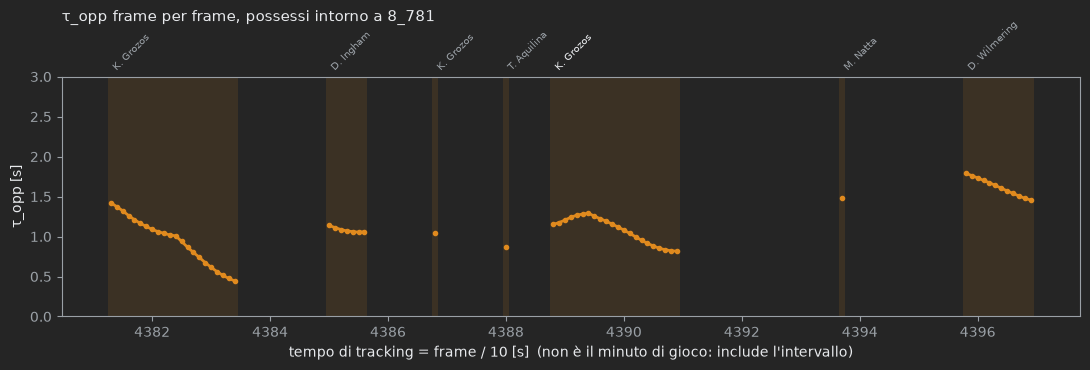

In [16]:
pp = de[(de.event_type == "player_possession") & (de.period == ev.period)].sort_values("frame_start")
vicini = pp[(pp.frame_end >= ev.frame_start - 80) & (pp.frame_start <= ev.frame_end + 80)]

fig, ax = plt.subplots(figsize=(11, 3.8), facecolor=BG)
ax.set_facecolor(BG); ax.tick_params(colors=MUTED)
for s in ax.spines.values():
    s.set_color(MUTED)
for p in vicini.itertuples():
    fr_ = np.arange(p.frame_start, p.frame_end + 1)
    tau_ = [dettaglio(f, p.player_id)[1]["τ [s]"].min() if p.player_position != "GK" else np.nan for f in fr_]
    c = colore[p.team_id]
    ax.axvspan(p.frame_start / FPS - 0.05, p.frame_end / FPS + 0.05, color=c, alpha=0.12, lw=0)
    ax.plot(fr_ / FPS, tau_, color=c, lw=2, marker="o", ms=3)
    ax.text(p.frame_start / FPS, 3.05, nome[p.player_id], color=INK if p.event_id == EVENT_ID else MUTED,
            fontsize=7.5, rotation=45, ha="left", va="bottom")
ax.set_ylim(0, 3)
ax.set_xlabel("tempo di tracking = frame / 10 [s]  (non è il minuto di gioco: include l'intervallo)", color=INK)
ax.set_ylabel("τ_opp [s]", color=INK)
ax.set_title(f"τ_opp frame per frame, possessi intorno a {EVENT_ID}", color=INK, loc="left", fontsize=10.5, pad=40)
plt.tight_layout(); plt.show()

**Cosa si vede.**

- A t_rel l'avversario decisivo è **un altro**: Gallegos, arrivato a 2 m.
  τ_opp scende da 1,15 a 0,82 s (−0,33 s), un calo dello stesso ordine della media
  del paper (0,28 s) e della nostra sulle 20 partite (0,26 s). SkillCorner va
  nella stessa direzione: `time_to_impact` passa da *easy* a *hard*.
- Nella serie, dentro i possessi più lunghi τ_opp **scende** mentre il portatore
  tiene palla (il primo possesso di Grozos va da 1,4 a 0,45 s), e al possesso
  successivo **riparte più alto** (Ingham 1,15 s, Natta 1,48 s). È il
  comportamento della Fig. 3 del paper. Nel nostro possesso c'è anche una breve
  salita iniziale (1,16 → 1,30 s), prima del calo.
- I punti isolati sono direct play (un solo frame); i vuoti fra le bande sono la
  palla in volo, senza portatore.
- Tutti i possessi in figura sono del Newcastle: è un'unica azione, quindi la
  "ripartenza" di τ_opp qui è fra compagni che si passano la palla, non fra squadre.

Un possesso solo non dimostra nulla: le distribuzioni sono in `reports/tau_opp.md`.

## 8. Verifica contro lo script

Lo stesso possesso, calcolato da tre strade: a mano qui sopra, con la funzione
dello script (`calcola_tau.pressione_al_frame`), e letto dal CSV prodotto sulle
20 partite. Devono coincidere.

In [17]:
avversari = [p for p, t in squadra.items() if t != ev.team_id]
confronto = []
for quando, frame, tab in (("start", ev.frame_start, tab_get), ("end", ev.frame_end, tab_rel)):
    s = calcola_tau.pressione_al_frame(frame, ev.player_id, avversari, f0, col, X, Y, VX, VY, D)
    confronto.append({"istante": quando, "a mano": tab["τ [s]"].min(), "script": s["tau_opp"],
                      "chi (a mano)": tab.player_id.iloc[0], "chi (script)": s["avv_tau_id"]})

csv = pd.read_csv("../reports/tau_opp.csv", low_memory=False)
riga = csv[(csv.match_id == MATCH_ID) & (csv.event_id == EVENT_ID)].iloc[0]
confronto[0]["CSV"], confronto[1]["CSV"] = riga.tau_opp_start, riga.tau_opp_end
confronto = pd.DataFrame(confronto)
assert np.allclose(confronto["a mano"], confronto["script"]) and np.allclose(confronto["a mano"], confronto["CSV"])
confronto

,istante,a mano,script,chi (a mano),chi (script),CSV
0,start,1.151,1.151,14736,14736,1.151
1,end,0.817,0.817,23418,23418,0.817


### E SkillCorner cosa dice?

`dynamic_events.csv` ha una misura propria, `time_to_impact_{start,end}`, in
cinque categorie (`very_easy` … `very_hard`). È un modello chiuso, quindi non si
può ricostruire; si può solo confrontare. Per questo possesso:

In [18]:
pd.DataFrame({
    "τ_opp [s]": [tab_get["τ [s]"].min(), tab_rel["τ [s]"].min()],
    "time_to_impact SkillCorner": [ev.time_to_impact_start, ev.time_to_impact_end],
}, index=["t_get", "t_rel"])

,τ_opp [s],time_to_impact SkillCorner
t_get,1.151,easy
t_rel,0.817,hard


Sulle 20 partite la correlazione di Spearman fra τ_opp e la categoria
`time_to_impact` è −0,86 all'inizio e −0,77 al rilascio (`reports/tau_opp.md`).
Prima di chiamarla validazione esterna va capito cosa c'è dentro il loro modello:
se è anch'esso un tempo di arrivo, le due misure non sono indipendenti. Il confronto
completo è nella §10.

## 9. Cosa è del paper e cosa è nostro

| | Paper (J1 League) | Qui (A-League, SkillCorner) |
|---|---|---|
| Modello, eq. 1–4 | Fujimura–Sugihara | identico |
| $\alpha$, $V_{\max}$ | 1,0 s⁻¹, 10 m/s | identici, non ricalibrati |
| Frequenza | 25 fps | 10 fps |
| Tracking | telecamere fisse | broadcast, con posizioni estrapolate |
| Velocità | Savitzky–Golay + spline, poi derivata | derivata centrale, nessuna lisciatura aggiunta |
| Intervalli di possesso | sincronizzazione propria evento-tracking | `player_possession` di SkillCorner |
| Posizione del portatore | "ball-carrier location" | posizione di tracking del giocatore |
| Soluzione dell'eq. 4 | "numerically" (non specificato) | primo attraversamento: griglia 0,01 s + `brentq` |
| Portieri | esclusi | esclusi (`player_position == "GK"`) |
| Qualità del dato | non discussa | `is_detected` dell'avversario che realizza τ_opp, salvato per ogni possesso |

Le righe in cui divergiamo sono le cose da dichiarare in qualunque risultato
costruito su τ_opp.

## 10. τ_opp e `time_to_impact`: misurano la stessa cosa?

Se SkillCorner fornisce già `time_to_impact` e la correlazione è −0,86, a cosa
serve calcolare τ_opp? Dipende da cosa c'è dentro la loro misura, e su questo la
documentazione dice poco:

- il README di `SkillCorner/opendata` dedica una riga a `time_to_impact`:
  *"how quickly an opponent could reach the player"*, in 5 classi da
  `very_easy` a `very_hard`, solo sulle righe `player_possession`;
- le *Dynamic Events CSV Specifications* (16/02/2025, 89 pagine) non la
  contengono affatto, e lo stesso vale per le altre sette metriche di pressione
  e difficoltà (`overall_pressure`, `space_constraint`, …).

Quindi il modello non si può leggere: si può solo interrogare dall'esterno, sui
20 match. Quattro domande:

1. le due misure sono prese **negli stessi istanti**?
2. **dove** esiste l'una e non l'altra?
3. quanta informazione si perde passando da secondi a **5 classi**?
4. `time_to_impact` è una **distanza** o, come τ_opp, tiene conto anche della
   **velocità** degli avversari?

Per la 4 serve una grandezza che il CSV non ha: la distanza dell'avversario più
vicino e la sua velocità verso il portatore. Si ricalcolano dal tracking con le
stesse funzioni dello script (circa 20 s per le 20 partite).

In [19]:
from scipy.stats import spearmanr, mannwhitneyu

tau = pd.read_csv("../reports/tau_opp.csv", low_memory=False)

def vicino_per_partita(match_id, righe):
    # Per ogni possesso, a inizio e fine: distanza dell'avversario più vicino e la
    # componente della sua velocità verso il portatore (positiva = si avvicina).
    squadra_ = {p["id"]: p["team_id"] for p in data.load_match_meta(match_id)["players"]}
    f0_, col_, X_, Y_, _, per_ = calcola_tau.carica_tracking(match_id)
    VX_, VY_ = calcola_tau.velocita_per_periodo(X_, Y_, per_)
    out = []
    for r in righe.itertuples():
        riga = {"match_id": match_id, "event_id": r.event_id}
        for q, frame in (("start", r.frame_start), ("end", r.frame_end)):
            i, jb = int(frame) - f0_, col_.get(r.player_id)
            if jb is None or not (0 <= i < X_.shape[0]) or not np.isfinite(X_[i, jb]):
                continue
            js = np.array([col_[p] for p, t in squadra_.items()
                           if t != r.team_id and p in col_ and np.isfinite(X_[i, col_[p]])])
            if not len(js):
                continue
            dx, dy = X_[i, jb] - X_[i, js], Y_[i, jb] - Y_[i, js]
            dist = np.hypot(dx, dy)
            k = int(np.argmin(dist))
            riga[f"d_min_{q}"] = dist[k]
            riga[f"v_verso_{q}"] = (VX_[i, js[k]] * dx[k] + VY_[i, js[k]] * dy[k]) / dist[k] if dist[k] > 0 else np.nan
        out.append(riga)
    return out

righe = [r for mid, g in tau.groupby("match_id") for r in vicino_per_partita(mid, g)]
tau = tau.merge(pd.DataFrame(righe), on=["match_id", "event_id"], how="left")
print(f"{len(tau)} possessi; d_min calcolata a inizio: {tau.d_min_start.notna().mean():.1%}")

17674 possessi; d_min calcolata a inizio: 99.7%


### 10.1 Stessi istanti?

τ_opp si calcola esattamente a `frame_start` e `frame_end`. Non sappiamo su
quale finestra lavori SkillCorner. Un controllo indiretto sono i *direct play*
(possessi di un solo frame, `frame_start == frame_end`): per noi inizio e fine
coincidono per costruzione. Se anche per SkillCorner le due classi coincidono
sempre, il loro "start" ed "end" sono legati al frame e non a una finestra che
si estende oltre il possesso.

In [20]:
dp = tau[tau.direct_play & tau.time_to_impact_start_id.notna() & tau.time_to_impact_end_id.notna()]
print(f"direct play con entrambe le classi: {len(dp)}; classe di inizio = classe di fine: "
      f"{(dp.time_to_impact_start_id == dp.time_to_impact_end_id).mean():.1%}")

direct play con entrambe le classi: 3242; classe di inizio = classe di fine: 100.0%


**Cosa si vede.** Nei direct play le classi di inizio e fine
coincidono sempre: anche per SkillCorner inizio e fine si riferiscono allo stesso
istante, quando il possesso dura un frame. Gli istanti sono quindi confrontabili.
Resta ignoto se la loro misura sia presa sul frame esatto o su una breve finestra
intorno.

### 10.2 Dove esiste l'una e non l'altra

In [21]:
copertura = []
for q in ("start", "end"):
    t_si, k_si = tau[f"tau_opp_{q}"].notna(), tau[f"time_to_impact_{q}_id"].notna()
    solo_tau = tau[t_si & ~k_si]
    copertura.append({
        "istante": q, "possessi": len(tau),
        "entrambe": (t_si & k_si).sum(), "solo τ_opp": len(solo_tau), "solo time_to_impact": (~t_si & k_si).sum(),
        "di cui direct play (solo τ_opp)": solo_tau.direct_play.sum(),
    })
display(pd.DataFrame(copertura).set_index("istante"))

print("time_to_impact presente, per tipo di possesso:")
print(tau.groupby("direct_play").time_to_impact_start_id.apply(lambda s: f"{s.notna().mean():.1%}")
      .rename(index={False: "possession play", True: "direct play"}).to_string())
print("\nstart_type dei possessi con solo τ_opp (inizio):")
print(tau[tau.tau_opp_start.notna() & tau.time_to_impact_start_id.isna()].start_type.value_counts().head(6).to_string())

,possessi,entrambe,solo τ_opp,solo time_to_impact,di cui direct play (solo τ_opp)
istante,,,,,
start,17674,16045,1521,1,1180
end,17674,16122,1541,1,1180


time_to_impact presente, per tipo di possesso:
direct_play
possession play    96.7%
direct play        73.1%

start_type dei possessi con solo τ_opp (inizio):
start_type
pass_interception     462
pass_reception        277
keep_possession       135
unknown               134
throw_in_reception    121
recovery              110


**Cosa si vede.** Le due misure mancano in casi diversi. τ_opp esiste
dovunque esista il tracking del portatore. `time_to_impact` manca in circa 1.500
possessi, e quasi 8 su 10 (1.180) sono direct play: SkillCorner non lo fornisce
in più di un direct play su quattro. Il caso opposto, `time_to_impact` presente
senza τ_opp, capita una volta sola. La correlazione −0,86 è calcolata quindi su
un sottoinsieme che esclude in parte i possessi di un tocco.

### 10.3 Secondi contro 5 classi

τ_opp è continuo; `time_to_impact` è una classe ordinale. Se le classi fossero
soglie sulla stessa grandezza, i τ_opp di classi diverse non si
sovrapporrebbero. Quanto si sovrappongono dice quanto le due misure divergono
*dentro* la correlazione.

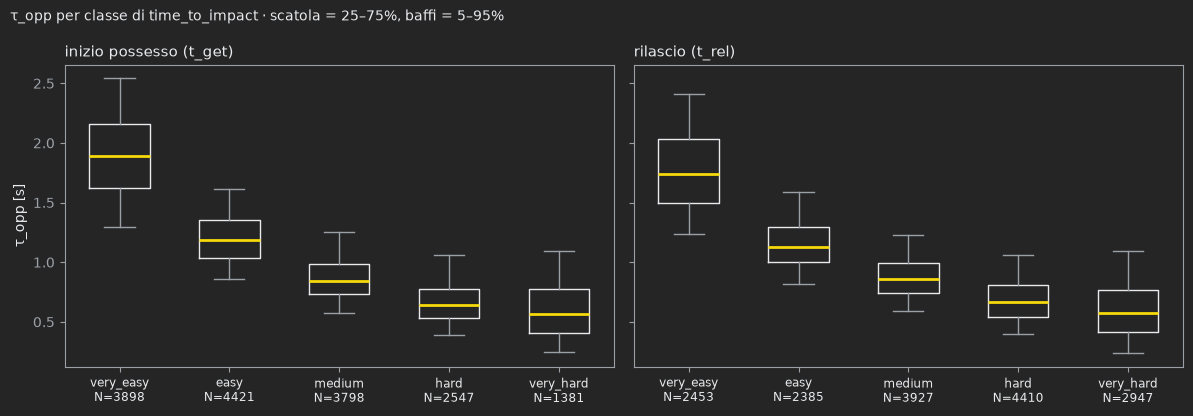

P(τ classe più facile > τ classe più difficile)       
istante                                                      end  start
coppia                                                                 
very_easy → easy                                           0.927  0.943
easy → medium                                              0.829  0.866
medium → hard                                              0.761  0.778
hard → very_hard                                           0.617  0.598

In [22]:
ETICHETTE = ["very_easy", "easy", "medium", "hard", "very_hard"]

fig, assi = plt.subplots(1, 2, figsize=(12, 4.2), facecolor=BG, sharey=True)
for a, q, titolo in zip(assi, ("start", "end"), ("inizio possesso (t_get)", "rilascio (t_rel)")):
    a.set_facecolor(BG); a.tick_params(colors=MUTED)
    for s in a.spines.values():
        s.set_color(MUTED)
    s_ = tau[[f"tau_opp_{q}", f"time_to_impact_{q}_id"]].dropna()
    gruppi = [s_.loc[s_[f"time_to_impact_{q}_id"] == k, f"tau_opp_{q}"] for k in range(1, 6)]
    a.boxplot(gruppi, whis=(5, 95), showfliers=False, widths=0.55,
              boxprops=dict(color=INK), medianprops=dict(color=SCIA, lw=2),
              whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
    a.set_xticks(range(1, 6), [f"{e}\nN={len(g)}" for e, g in zip(ETICHETTE, gruppi)], color=INK, fontsize=8.5)
    a.set_title(titolo, color=INK, loc="left", fontsize=10.5)
assi[0].set_ylabel("τ_opp [s]", color=INK)
fig.suptitle("τ_opp per classe di time_to_impact · scatola = 25–75%, baffi = 5–95%",
             color=INK, x=0.01, ha="left", fontsize=10)
plt.tight_layout()
plt.show()

# quanto si sovrappongono classi adiacenti: P(τ di un possesso della classe k > τ di uno della k+1)
# 1 = separate del tutto, 0,5 = indistinguibili (è l'AUC della coppia)
sep = []
for q in ("start", "end"):
    s_ = tau[[f"tau_opp_{q}", f"time_to_impact_{q}_id"]].dropna()
    for k in range(1, 5):
        a_, b_ = (s_.loc[s_[f"time_to_impact_{q}_id"] == c, f"tau_opp_{q}"] for c in (k, k + 1))
        sep.append({"istante": q, "coppia": f"{ETICHETTE[k-1]} → {ETICHETTE[k]}",
                    "P(τ classe più facile > τ classe più difficile)": mannwhitneyu(a_, b_).statistic / (len(a_) * len(b_))})
pd.DataFrame(sep).pivot(index="coppia", columns="istante").reindex(
    [f"{ETICHETTE[k-1]} → {ETICHETTE[k]}" for k in range(1, 5)]).round(3)

**Cosa si vede.** Le classi sono ordinate come τ_opp, ma la separazione
cala man mano che la pressione cresce. `very_easy` e `easy` si distinguono
quasi sempre (0,94 all'inizio). `hard` e `very_hard` sono quasi indistinguibili
(0,60): per τ_opp `very_hard` va da 0,25 a 1,1 s, cioè contiene possessi con
l'avversario praticamente addosso e altri lontani un secondo. Proprio nella zona
che interessa di più, dove la pressione è alta, la scala a 5 classi è la più
grossolana. La §10.4 mostra il motivo: sotto i 2 m di distanza la classe è
sempre `very_hard`.

### 10.4 Distanza o tempo di arrivo?

τ_opp dipende da due cose: quanto è lontano l'avversario e come si muove. Una
misura di sola distanza vedrebbe soltanto la prima. Due prove:

- **correlazione complessiva**: `time_to_impact` va più d'accordo con τ_opp o con
  la distanza dell'avversario più vicino?
- **a parità di distanza**: fra possessi con l'avversario più vicino alla stessa
  distanza, quelli in cui l'avversario corre verso il portatore sono classificati
  più difficili? Se `time_to_impact` fosse una distanza, a distanza fissa la
  velocità non conterebbe.

In [23]:
glob = []
for q in ("start", "end"):
    s_ = tau[[f"time_to_impact_{q}_id", f"tau_opp_{q}", f"d_min_{q}"]].dropna()
    glob.append({"istante": q, "N": len(s_),
                 "ρ con τ_opp": spearmanr(s_.iloc[:, 0], s_.iloc[:, 1])[0],
                 "ρ con distanza dell'avversario più vicino": spearmanr(s_.iloc[:, 0], s_.iloc[:, 2])[0]})
display(pd.DataFrame(glob).set_index("istante").round(3))

FASCE = [0, 1, 2, 3, 4, 5, 6, 8, 10, 15]
parita = []
for q in ("start", "end"):
    s_ = tau[[f"time_to_impact_{q}_id", f"d_min_{q}", f"v_verso_{q}"]].dropna()
    s_["fascia"] = pd.cut(s_[f"d_min_{q}"], FASCE)
    for f, g in s_.groupby("fascia", observed=True):
        parita.append({"istante": q, "distanza [m]": str(f), "N": len(g),
                       "classe mediana": g[f"time_to_impact_{q}_id"].median(),
                       "ρ(classe, v verso il portatore)": spearmanr(g[f"time_to_impact_{q}_id"], g[f"v_verso_{q}"])[0]})
pd.DataFrame(parita).pivot(index="distanza [m]", columns="istante").reindex(
    [str(pd.Interval(a, b)) for a, b in zip(FASCE[:-1], FASCE[1:])]).round(2)

,N,ρ con τ_opp,ρ con distanza dell'avversario più vicino
istante,,,
start,16045,-0.864,-0.913
end,16122,-0.770,-0.912


N       classe mediana       ρ(classe, v verso il portatore)      
istante        end start            end start                             end start
distanza [m]                                                                       
(0, 1]        1203   459            5.0   5.0                           -0.02  0.04
(1, 2]        3058  1360            5.0   5.0                           -0.02  0.03
(2, 3]        2988  1749            4.0   4.0                            0.16  0.12
(3, 4]        2357  1809            3.0   3.0                            0.33  0.22
(4, 5]        1710  1603            3.0   3.0                            0.41  0.36
(5, 6]        1203  1552            2.0   2.0                            0.47  0.43
(6, 8]        1468  2388            2.0   2.0                            0.46  0.33
(8, 10]        885  1774            1.0   2.0                            0.41  0.41
(10, 15]      1092  2701            1.0   1.0                            0.18  0.33

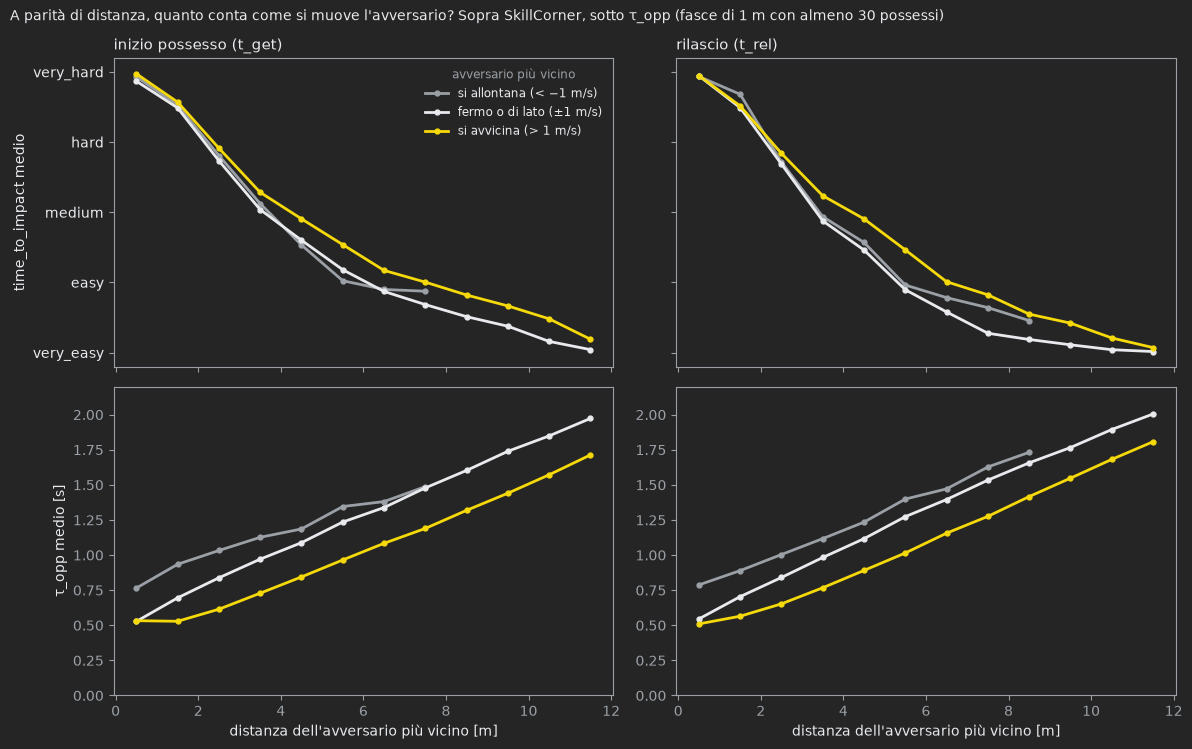

In [24]:
# La stessa prova in figura, per le due misure sugli stessi possessi: valore medio per
# fascia di distanza, separando chi si allontana, chi è fermo o si muove di lato, e
# chi corre verso il portatore.
GRUPPI_V = [(-np.inf, -1, "si allontana (< −1 m/s)", MUTED), (-1, 1, "fermo o di lato (±1 m/s)", INK),
            (1, np.inf, "si avvicina (> 1 m/s)", SCIA)]
fig, assi = plt.subplots(2, 2, figsize=(12, 7.6), facecolor=BG, sharex=True)
for colonna, (q, titolo) in enumerate((("start", "inizio possesso (t_get)"), ("end", "rilascio (t_rel)"))):
    s_ = tau[[f"time_to_impact_{q}_id", f"tau_opp_{q}", f"d_min_{q}", f"v_verso_{q}"]].dropna()
    s_ = s_[s_[f"d_min_{q}"] < 12]
    s_["fascia"] = (s_[f"d_min_{q}"] // 1) + 0.5
    for riga_, (misura, etichetta_y) in enumerate(((f"time_to_impact_{q}_id", "time_to_impact medio"),
                                                   (f"tau_opp_{q}", "τ_opp medio [s]"))):
        a = assi[riga_, colonna]
        a.set_facecolor(BG); a.tick_params(colors=MUTED)
        for s in a.spines.values():
            s.set_color(MUTED)
        for lo, hi, nome_, c in GRUPPI_V:
            g = s_[(s_[f"v_verso_{q}"] > lo) & (s_[f"v_verso_{q}"] <= hi)].groupby("fascia")[misura]
            m_ = g.mean()[g.size() >= 30]
            a.plot(m_.index, m_.values, color=c, lw=2, marker="o", ms=3.5, label=nome_)
        if riga_ == 0:
            a.set_title(titolo, color=INK, loc="left", fontsize=10.5)
            a.set_yticks(range(1, 6), ETICHETTE if colonna == 0 else [], color=INK)
            a.set_ylim(0.8, 5.2)
        else:
            a.set_xlabel("distanza dell'avversario più vicino [m]", color=INK)
            a.set_ylim(0, 2.2)
        if colonna == 0:
            a.set_ylabel(etichetta_y, color=INK)
assi[0, 0].legend(frameon=False, labelcolor=INK, fontsize=8.5, title="avversario più vicino",
                  title_fontproperties=dict(size=8.5)).get_title().set_color(MUTED)
fig.suptitle("A parità di distanza, quanto conta come si muove l'avversario? Sopra SkillCorner, sotto τ_opp "
             "(fasce di 1 m con almeno 30 possessi)", color=INK, x=0.01, ha="left", fontsize=10)
plt.tight_layout()
plt.show()

**Cosa si vede.**

- **Nel complesso `time_to_impact` va più d'accordo con la distanza che con
  τ_opp**: ρ = −0,91 in entrambi gli istanti, contro −0,86 e −0,77. Il distacco
  è più ampio al rilascio, e lì la distanza tiene mentre τ_opp perde.
- **Però non è solo una distanza.** A parità di distanza, fra 3 e 10 m, la
  classe sale con la velocità dell'avversario verso il portatore (ρ fra 0,2 e
  0,47 dentro ogni fascia). Il loro modello quindi tiene conto del moto, e con
  ogni probabilità è anch'esso un tempo di arrivo. Sotto i 2 m la velocità non
  conta più perché la classe è già `very_hard`: è il tetto della scala.
- **Il moto conta in modo diverso.** In τ_opp, sotto, l'avversario che si
  allontana impiega più tempo di quello fermo, come vuole il modello di
  Fujimura–Sugihara (§2). In SkillCorner, sopra, chi si allontana non viene
  classificato più facile di chi sta fermo: conta solo chi si avvicina. Con una
  riserva: i possessi con l'avversario più vicino che si allontana sono pochi,
  30–80 per fascia, e quando il più vicino si allontana τ_opp può passare a un
  altro avversario.

Perché τ_opp perda contro la distanza, soprattutto al rilascio, da qui non si
decide. Ci sono due spiegazioni compatibili con i dati:
1. **il loro modello dà meno peso alla velocità del nostro**: al rilascio gli
   avversari sono più spesso lanciati, quindi la differenza si vede di più;
2. **le nostre velocità sono rumorose** (derivata a 10 fps senza lisciatura, §5),
   e il rumore entra in τ_opp ma non nella distanza.

Per separarle si può ricalcolare τ_opp con velocità lisciate (`velocita(...,
finestra=5)`) e vedere se la correlazione risale.

## 11. Allora a cosa serve calcolare τ_opp?

**Le due misure calcolano idee vicine, ma non la stessa cosa.** Dai 20 match
`time_to_impact` risulta così:
- una scala a 5 classi dominata dalla distanza dell'avversario più vicino;
- corretta per la velocità di chi si avvicina, ma non di chi si allontana;
- satura sotto i 2 m (`very_hard`) e oltre i 10 m circa (`very_easy`);
- assente in un direct play su quattro.

τ_opp invece è un tempo in secondi, che viene da un modello fisico simmetrico
con parametri dichiarati.

Per la stessa ragione **la correlazione −0,86 non è una validazione esterna**:
le due misure condividono la componente principale, la distanza. Dice che il
nostro calcolo non è sbagliato in modo grossolano, e niente di più.

Se servisse solo un'etichetta "pressione alta / bassa" a inizio e fine
possesso, `time_to_impact` basterebbe. τ_opp serve per tutto il resto:

| | `time_to_impact` | τ_opp |
|---|---|---|
| Modello | chiuso, non documentato (una riga nel README) | pubblicato, ogni passo in questo notebook |
| Scala | 5 classi, satura dove la pressione è alta | secondi, continua |
| Dove | solo inizio e fine di `player_possession` | qualunque frame, qualunque punto del campo, qualunque giocatore |
| Chi realizza la pressione | non si sa | si sa, e si sa se era osservato (`is_detected`) |
| Direct play | manca nel 27% | sempre, se c'è tracking |
| Varianti del paper | no | τ_same, τ_opp − τ_same alla destinazione del passaggio, serie frame per frame (§7) |

Le ultime tre righe sono quelle che contano per la pista A. Lo studio di
robustezza all'estrapolazione chiede quale avversario determina la pressione e
se la telecamera lo vedeva, e un modello chiuso a 5 classi non lo può dire.